# A/B TESTING: frequentist and bayesian approach

In data science we focused on **ESTIMATION** and **PREDICTION** (using data to make informed guesses about unknown values or future outcomes). Estimation refers to determining the likely value of population parameters (e.g., mean, variance), while prediction involves forecasting future observations based on known data.

**INFERENTIAL STATISTICS**, on the other hand, focuses on drawing conclusions about a population based on a sample. It involves hypothesis testing and making generalizations from data, providing insight into the broader patterns or relationships that exist beyond the data at hand.

**Q**: How decisions are made in a company?
1. **HIPPO**: stands for "Highest Paid Person's Opinion." It refers to a decision-making dynamic where the opinion or judgment of the most senior or highly-paid individual in a group is given more weight.
2. **Decision Science**: is the interdisciplinary study that combines data analysis, statistics, psychology, and economics to help make informed, data-driven decisions. It focuses on understanding how decisions are made and how they can be optimized using quantitative and qualitative methods.



### A/B testing
**A/B testing**, traditionally used in marketing and product development, is a powerful statistical method to compare two versions of a variable or a piece of software or a feature (A and B) to determine which one performs better on a specific outcome, allowing to make data-driven decisions by statistically validating which option is more effective or preferable. In data science A/B testing is commonly used to evaluate unsupervised models, which typically have no metrics. A/B testing allow to compare the effectiveness of different models or techniques when there's no clear "right" answer or labeled data. It helps us determine which approach better captures patterns, improves downstream tasks, or achieves specific goals, even without predefined outcomes.

### Why A/B testing and not A/B/C... testing?

1. **Simplicity**:
 A/B testing compares two versions (A and B), making it easier to interpret results and focus on a clear decision. Adding a third version (C) increases complexity.

2. **Statistical Power**:
 A/B tests require fewer data points to achieve statistical significance. In A/B/C testing, the same sample is split into three groups, reducing the power of each comparison, potentially leading to inconclusive results.

3. **Clarity of Results**:
 A/B tests provide a straightforward comparison between two options. A/B/C testing introduces multiple comparisons, increasing the risk of false positives and complicating the decision process.

4. **Resource Efficiency**:
 Testing more variants (A/B/C) requires more resources, time, and larger sample sizes to achieve reliable results, making it less practical for many applications.


### Two practical approaches - frequentist and bayesian approach

In the following tutorial we will use available data from kaggle () and analize them using two different approaches:

- **Frequentist Approach**: This involves using hypothesis testing (e.g., t-tests, chi-square tests) to determine if there is a statistically significant difference between the two versions. The null hypothesis typically assumes no difference between A and B, and a p-value is calculated to assess this.

- **Bayesian Approach**: Bayesian A/B testing involves updating the probability of a hypothesis as more data becomes available. Instead of relying on p-values, the Bayesian method calculates the posterior probability distribution of the effect size, giving a more intuitive measure of which version is better and by how much.


**Hands-on Content**:
1. Experiment definition
2. Data collection
3. Data cleaning and feature engineering
4. Univariate analysis
5. Multivariate analysis
6. Frequentist approach:
    - what's p-value?
    - let's calculate the p-value
7. Bayesian approach:
    - Updating of information

In [1]:
# Import required libraries for data analysis and statistical testing
# - pandas/numpy: data manipulation
# - datetime: timestamp processing
# - seaborn: visualization
# - scipy.stats: statistical tests (chi-square test, beta distribution)
import pandas as pd
import numpy as np
import datetime
import seaborn as sns

from scipy.stats import chi2_contingency, beta
from statsmodels.stats.power import GofChisquarePower

# 1. Experiment Definition

![pipeline](./Picture/Stat_inference_pipeline.png)

### Key Elements to Consider When Formulating a Hypothesis and Designing an A/B Test::


1. **Creation of Random Groups**

    _How are they created?_

    Random groups are typically created by assigning participants randomly into two (or more) groups, ensuring each individual has an equal chance of being in either group (A or B).
    
    _Ensuring true randomness_

    Use algorithms or random number generators to avoid biases. Ensure that external factors (e.g., time of day, geographic location) don't unintentionally skew group membership. Tools like random sampling or stratified sampling can help in cases where specific characteristics need to be balanced across groups.

    In our example we developed a new webpage and want to test it's effects on purchase conversion. As such we split our users evenly into 2 groups:
    1. **Control**: They get the old webpage,
    2. **Treatment**: They get the new webpage.


2. **Success Metric (Which Metric Are You Using to Compare the Two Groups?)**
    Choose a metric that aligns with your business goals and reflects meaningful differences. Common success metrics include:

    _Conversion Rate_: Percentage of users completing a desired action (e.g., making a purchase).
    
    _Click-Through Rate (CTR)_: Percentage of users who clicked on a specific element.
    
    _Engagement_: Time spent on a page or interaction with features.
    
    _Revenue per User (RPU)_: Average revenue generated by each user in each group.
    
    _Retention Rate_: Percentage of users who return after a specified time.
    
    _Lift_: The difference in performance between the treatment and control groups, expressed as either an absolute difference (percentage points) or relative difference (percent change). Lift measures the impact of the change being tested. For example:
    - **Absolute Lift**: Treatment conversion rate (12%) - Control conversion rate (10%) = 2 percentage points
    - **Relative Lift**: (Treatment - Control) / Control × 100 = (12% - 10%) / 10% × 100 = 20% improvement
    
    A positive lift indicates the treatment performs better, while a negative lift suggests the control is superior.
    
    In our example the metric we want to track:

    $$\
    purchaseConversion = \frac{Converted Users}{Exposed Users}
    $$

3. **Time**

- seasonal effects
- having some preliminary data ongoing view
- coordination with other department (to check for cofounder events)

# Additional explanation ELI10

Here is an "Explain Like I'm 10" (ELI10) breakdown of those four concepts using simple, everyday analogies!

### 1. Chi-Square (The "Expectation vs. Reality" Test)

Imagine a candy factory claims their bags of M&Ms are always perfectly mixed: 50% Red and 50% Blue.

You open a bag with 100 M&Ms. If you get 52 Red and 48 Blue, you'd probably say, *"Close enough, that's just normal luck."* But if you open it and get **90 Red and 10 Blue**, you would instantly know the factory's machine is broken.

**Chi-Square** is just a math tool that acts as a lie detector for counts and categories. It measures the gap between what you *expected* to see (50/50) and what *actually* happened (90/10). If the gap is huge, the Chi-Square alarm goes off to tell you that something real is happening, and it's not just random luck.

### 2. p-value (The "Luck Meter")

Imagine your friend claims they have magic powers and can flip a coin and get "Heads" every time.

* They flip it once and get Heads. You think: *"50% chance, that's just luck."*
* They flip it 10 times in a row and get Heads every time.

The **p-value** is the exact mathematical percentage that measures **how likely it is that this happened purely by accident.** If your friend gets 10 Heads in a row, the p-value (the chance of pure luck) drops to about 0.001 (0.1%). Because the "Luck Meter" is so incredibly low, you can confidently say, *"This isn't luck. You are using a trick coin."* In A/B testing, a low p-value (usually under 0.05) means your new webpage is *actually* better, not just getting lucky.

---

### 3. Frequentist Execution (The "Strict Referee")

The Frequentist approach is like a very strict sports referee holding a stopwatch.

Before the game even starts, the referee says: *"I don't care which team is better. We are going to play exactly 100 games. I will not look at the score, and I will not make a decision until the very last second of the 100th game. Once the time is up, we will look at the p-value. If it crosses the finish line, Team A wins. If not, it's a tie."*

**Key traits:** It relies entirely on a fixed set of rules, it requires you to wait until the test is completely finished to peek at the results, and it doesn't care about anything that happened in the past.

### 4. Bayesian Execution (The "Smart Detective")

The Bayesian approach is like a detective trying to solve a case, constantly updating their notebook as new clues arrive.

Before the test even starts, the detective writes down what they *already know* (e.g., "The old webpage is usually pretty good"). This is called the **Prior**.
Then, instead of waiting for 100 games to finish, the detective watches every single visitor click on the website in real-time.

* "Oh, someone bought something on the new page. I am now 55% sure the new page is better."
* "Three more people bought something! Now I am 80% sure it's better."
* "Wow, 10 more sales. I am now 99% sure it's better. Case closed, we don't even need to finish the 100 games!" (This is the **Posterior**).

**Key traits:** It learns as it goes. It combines what you *used* to know with *new* evidence, and instead of a strict "Yes/No" rule, it gives you a continuously updating percentage (like "I am 85% sure the new page is better").

Here is an "Explain Like I'm 10" breakdown of the Significance Level (Alpha), building right off the "Luck Meter" from our last explanation!

## Alpha (The "Line in the Sand")

Remember how the **p-value** is the "Luck Meter"—a percentage that tells you how likely it is that something happened purely by accident?

The **Significance Level (Alpha)** is the exact rule you make up *before* you start testing. It is your personal "Line in the Sand" for when you stop believing in luck.

Let's go back to your friend with the magic coin.

* Before they start flipping, you have to decide: *"How many times do they have to get Heads in a row before I officially call them a cheater?"*
* You decide: *"I will only call them a cheater if the chance of this being pure luck drops **below 5%**."*

That **5%** (often written as 0.05) is your Alpha!

Now, your friend starts flipping:

1. They get 4 Heads in a row. The Luck Meter (p-value) drops to **6%**.
* *Your brain:* "6% is suspicious, but it is still higher than my 5% rule. I'll let it slide. It might just be luck." (Not statistically significant).


2. They get 5 Heads in a row. The Luck Meter (p-value) drops to **3%**.
* *Your brain:* "Aha! 3% is lower than my 5% rule! You crossed the Line in the Sand!" You yell, "Cheater!" (Statistically significant).



**The Golden Rule of A/B Testing:**

* If the p-value is **LOWER** than your Alpha: You found something real! (The new webpage actually works).
* If the p-value is **HIGHER** than your Alpha: It's just noise and luck. (The new webpage didn't actually do anything special).

Here is a quick interactive simulator to see exactly how Alpha and the p-value work together to make a decision. Try moving the "Line in the Sand" and the "Luck Meter" to see when the alarm triggers!

# 2. Data Collection

Let's use some A/B testing data: https://www.kaggle.com/saraabdelaal/abtestdata

In [2]:
# Load the A/B test data from CSV file
# Display first 5 rows to understand the structure
df = pd.read_csv("data/ab_data.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
# DATA EXPLORATION: Summarize the dataset
# Check total observations, unique users, duplicates, and column names
print(f"""The dataframe contains {df.shape[0]} observations, and {df["user_id"].nunique()} is a unique entry. 
Therefore, there are {int(df.duplicated(subset="user_id").sum())} duplicate entries.
It includes {df.shape[1]} columns, specifically {list(df.columns)}.
""")

The dataframe contains 294478 observations, and 290584 is a unique entry. 
Therefore, there are 3894 duplicate entries.
It includes 5 columns, specifically ['user_id', 'timestamp', 'group', 'landing_page', 'converted'].



In [4]:
# TEMPORAL ANALYSIS: Analyze the experiment duration and group distribution
# Parse timestamps to determine experiment duration
# Check if control and treatment groups are balanced (should be ~50% each)
start_time = datetime.datetime.strptime(df["timestamp"].min(), "%Y-%m-%d %H:%M:%S.%f")
end_time = datetime.datetime.strptime(df["timestamp"].max(), "%Y-%m-%d %H:%M:%S.%f")
data_duration = end_time - start_time

print(f"""The data are collected for {data_duration} days.
Users in the control group are {round(df[df["group"] == "control"].shape[0] * 100 / df.shape[0])} percent of the total users.      
      """)

The data are collected for 21 days, 23:59:49.081927 days.
Users in the control group are 50 percent of the total users.      
      


##

**Columns description**:
- **user_id**: user identifier number;
- **timestamp**: when the user was first exposed to the group
- **group**: control or treatment, A or B, bucket in which the user is placed
- **landing_page**: page the user is actually seeing
- **converted**: initialized as 0, turn to 1 when the user makes a purchase

In [5]:
# Count the number of duplicate user_id entries
# This helps us understand data quality issues
int(df.duplicated(subset="user_id").sum())

3894

3894 entries are duplicated


# 3. Data cleaning and feature engineering

In [6]:
# IDENTIFY DUPLICATED USERS: Find all user_ids that appear multiple times
# This includes users who were tracked more than once in the experiment
ids = df["user_id"]
repeated_user = df[ids.isin(ids[ids.duplicated()])]["user_id"]
repeated_user

22        767017
192       656468
226       773693
240       733976
246       704650
           ...  
294308    905197
294309    787083
294328    641570
294331    689637
294355    744456
Name: user_id, Length: 7788, dtype: int64

In [7]:
# EXAMPLE OF DUPLICATE: Show a sample user who appears multiple times
# User 744456 appears twice, exposed to different pages
sample = df[df["user_id"].isin([744456])]
sample

,user_id,timestamp,group,landing_page,converted
241565,744456,2017-01-11 06:14:35.761189,treatment,old_page,0
294355,744456,2017-01-13 09:32:07.106794,treatment,new_page,0


Some users are tracked more than once and may have been exposed to different treatment conditions (different groups or different landing pages). These contaminated users should be removed to ensure clean experimental data.

In [8]:
# DATA CLEANING: Remove contaminated users
# Contaminated users are those who were exposed to multiple treatment conditions:
# 1. Users who appeared in both control AND treatment groups
# 2. Users who saw both old_page AND new_page

# Identify users who appeared in both control and treatment groups
users_both_groups = df.groupby("user_id")["group"].nunique()
users_both_groups = users_both_groups[users_both_groups > 1].index

# Identify users who saw both landing pages
users_both_pages = df.groupby("user_id")["landing_page"].nunique()
users_both_pages = users_both_pages[users_both_pages > 1].index

# Combine both sets of contaminated users
contaminated_users = set(users_both_groups) | set(users_both_pages)

# Remove contaminated users from the dataset
df = df[~df["user_id"].isin(contaminated_users)]
print(f"Removed {len(contaminated_users)} contaminated users:")
print(f"  - {len(users_both_groups)} users in both groups")
print(f"  - {len(users_both_pages)} users saw both pages")

# Keep only the first timestamp per user (remove any remaining duplicates)
# This handles users who have duplicate entries with identical conditions
first_exposure = df.groupby("user_id")["timestamp"].min().reset_index()
df = df.merge(first_exposure, on=["user_id", "timestamp"])
print(f"Dataframe shape after cleaning: {df.shape}")

Removed 3893 contaminated users:
  - 1895 users in both groups
  - 1998 users saw both pages
Dataframe shape after cleaning: (286691, 5)


In [9]:
# Verify that we have no duplicate users after cleaning
num_unique_users = df["user_id"].nunique()
total_rows = len(df)
print(f"Total rows after cleaning: {total_rows}")
print(f"Unique users: {num_unique_users}")
print(f"All users are unique: {num_unique_users == total_rows}")

Total rows after cleaning: 286691
Unique users: 286691
All users are unique: True


In [10]:
# FEATURE ENGINEERING: Extract time features from timestamp
# We extract the week number to analyze temporal patterns in the experiment
df["week"] = df["timestamp"].apply(
    lambda x: datetime.datetime.strptime(x, "%Y-%m-%d %H:%M:%S.%f").isocalendar()[1]
)
df.sample()

,user_id,timestamp,group,landing_page,converted,week
72632,867491,2017-01-12 03:25:37.010604,treatment,new_page,0,2


In [11]:
# FEATURE ENGINEERING: Binary encoding for categorical variables
# We use simple 0/1 mapping (not one-hot encoding) since we only have 2 categories each
# This creates a clear, intuitive mapping where:
#   - control (baseline) = 0, treatment (intervention) = 1
#   - old_page (baseline) = 0, new_page (new variant) = 1

df["group_bin"] = df["group"].map({"control": 0, "treatment": 1})
df["landing_page_bin"] = df["landing_page"].map({"old_page": 0, "new_page": 1})

# Verify the encoding worked correctly
print("Encoding verification:")
print(
    df[["group", "group_bin", "landing_page", "landing_page_bin"]]
    .drop_duplicates()
    .sort_values(["group", "landing_page"])
)

df.sample(5)

Encoding verification:
       group  group_bin landing_page  landing_page_bin
0    control          0     old_page                 0
2  treatment          1     new_page                 1


,user_id,timestamp,group,landing_page,converted,week,group_bin,landing_page_bin
37093,750058,2017-01-08 06:47:43.355828,treatment,new_page,1,1,1,1
150911,633396,2017-01-14 19:46:55.380167,treatment,new_page,0,2,1,1
254984,665977,2017-01-07 06:22:57.019831,treatment,new_page,0,1,1,1
91638,690363,2017-01-11 02:16:36.640693,control,old_page,0,2,0,0
248332,906907,2017-01-13 14:56:51.232149,control,old_page,0,2,0,0


In [12]:
# Create a working dataset with only numerical/analytical columns
# Remove user_id and timestamp (identifiers), and categorical text columns
# This leaves us with: converted, week, group_bin, landing_page_bin
working_df = df.drop(["user_id", "timestamp", "group", "landing_page"], axis=1)
working_df

,converted,week,group_bin,landing_page_bin
0,0,3,0,0
1,0,2,0,0
2,0,2,1,1
3,0,1,1,1
4,1,3,0,0
...,...,...,...,...
286686,0,1,0,0
286687,0,2,0,0
286688,0,3,0,0
286689,0,2,0,0



# 4. Univariate analysis

Univariate analysis focuses on analyzing a single variable to understand its distribution, central tendency, and variability. It's used to summarize data through measures like mean, median, and standard deviation, often as a preliminary step in data exploration.

# 5. Multivariate analysis

Multivariate analysis examines multiple variables simultaneously to understand relationships, patterns, and interactions between them. It's used for complex data exploration, dimensionality reduction, and modeling real-world phenomena where multiple factors influence outcomes.

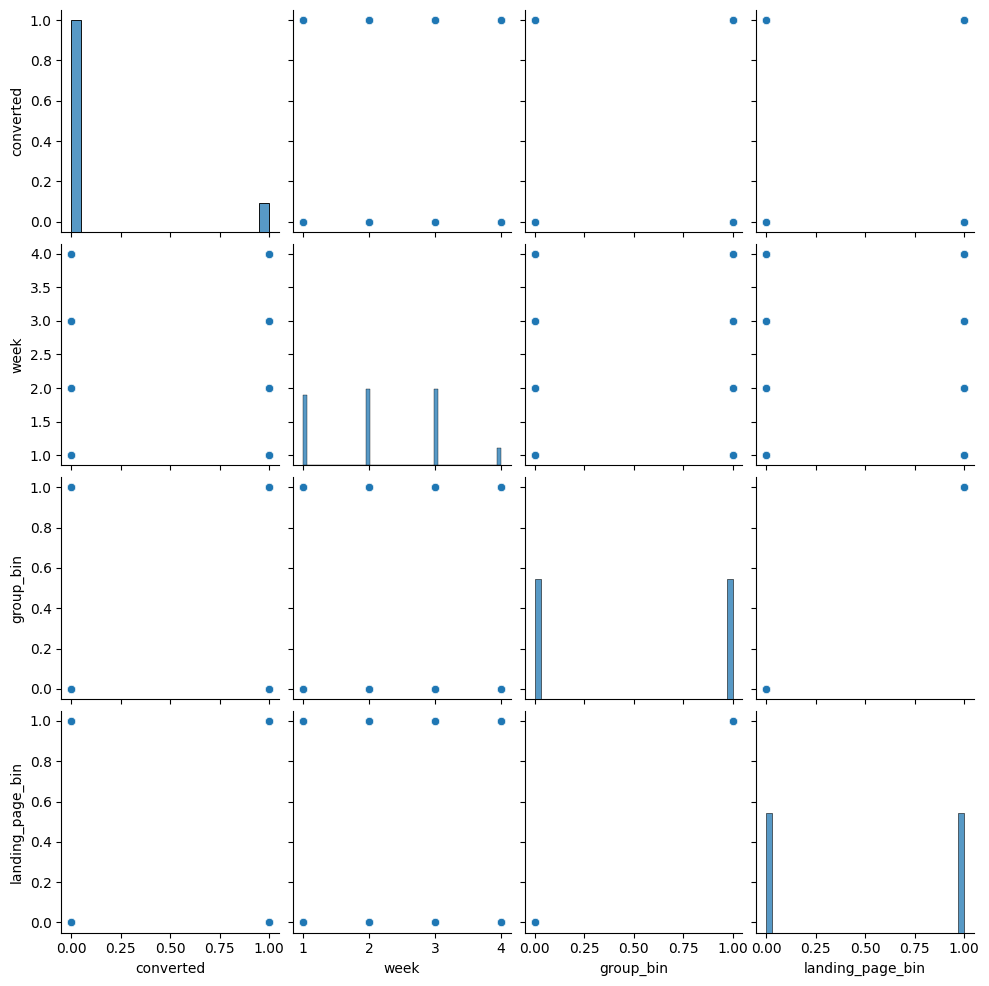

In [13]:
# MULTIVARIATE VISUALIZATION: Create pairplot to explore relationships
# Shows distributions and correlations between all numerical variables
sns.pairplot(working_df)

# 6. Statistical analysis: FREQUENTIST APPROACH

The **frequentist approach** is a classical statistical framework where probabilities represent the long-run frequency of events.


### Hypothesis formulation: 

- **Define the Null Hypothesis (H₀)**
    The **null hypothesis (H₀)** in A/B testing assumes that there is no difference between the two groups (A and B), meaning any observed difference is due to random chance. The goal is to test whether the observed difference between groups is more extreme than what would reasonably occur by chance alone. If the data shows that the difference is statistically significant, the test results show that the probability of observing such a difference by chance (p-value) is below a predefined significance level (e.g., p < 0.05) (i.e., unlikely to be due to chance, ), we can **reject the null hypothesis**. If not, we fail to reject H₀, but this doesn’t prove it's true—just that there's insufficient evidence against it. We can conclude that the groups differ in a meaningful way. However, if the difference isn’t significant, we fail to reject the null hypothesis, indicating that we don't have enough evidence to claim a true difference. 

In our example:  
H₀: convertion rate in group A = conversion rate in group B 

- **Alternate Hypothesis (H₁)**
    The alternative hypothesis (H₁) posits that there is a **real difference** between the two groups (A and B) in an A/B test. It suggests that any observed difference is not due to random chance, but rather reflects a genuine effect or variation caused by the experimental change.

In our example:
H₁= convertion rate in group A != conversion rate in group B 


- **Statistical test**

We perform **statistical tests** to determine if observed data provide enough evidence to reject the null hypothesis (H₀), which assumes no effect or difference between groups. Statistical tests evaluate whether the observed difference could be due to random chance. The choice of a statistical test in A/B testing depends on the **nature of the data** and its **distribution**:

**1. For Normally Distributed Data (Parametric Tests)**:

Use parametric tests when the data follows a normal distribution, and sample sizes are large enough.
Common Tests:
    
- T-test: Used for comparing the means of two groups (e.g., comparing average conversion rates).
    
- ANOVA: Used when comparing more than two groups or variations.

**2. For Non-Normal Data (Non-Parametric Tests)**:

 Use non-parametric tests when the data doesn’t follow a normal distribution or when the sample size is small.
Common Tests:

- Mann-Whitney U Test: Compares medians between two groups, useful for skewed data.

- Kruskal-Wallis Test: Extends the Mann-Whitney test to more than two groups.

**3. For Categorical Data**:

If your data involves counts or proportions (e.g., conversion rates, click-through rates), and you want to compare frequencies. Common Tests:

- Chi-square Test: Compares proportions between groups for categorical data.

- Fisher's Exact Test: Used for small sample sizes when comparing categorical data.


- **Control for statistical power**
    A power test measures the ability of an A/B test to detect a true effect or difference between groups if one exists. The power of a test is the probability of correctly rejecting the null hypothesis when the alternative hypothesis is true (i.e., avoiding a Type II error). Typically, a power of 80% or higher is desired, meaning the test has an 80% chance of detecting a true difference.


| Reality/Study | There are significant effects (H0 rejected) | There are NO significant effects |
| --- | --- | --- |
| Test B is different than test A (H0 true)  | CORRECT (Power) | Type II error |
| Test B is NOT different than test A (H0 true) | Type I error | CORRECT |



The power depends on several factors:

- Sample size: Larger sample sizes increase power.

- Effect size: Bigger differences between groups are easier to detect.
    
- Significance level (α): A lower significance level (e.g., 0.05) reduces the risk of Type I error but may reduce power.
 
 Many online tools, for example: https://abtestguide.com/calc/




In [14]:
# FREQUENTIST APPROACH: Calculate descriptive statistics for both groups
# Filter data for first 3 weeks of the experiment
# Calculate conversion rates and lift (difference between treatment and control)
NUM_WEEKS = 3  # Vary number to get experiment data at weekly points in time
experiment_data = df[df["week"] <= NUM_WEEKS]
control = experiment_data[experiment_data["group"] == "control"]
treatment = experiment_data[experiment_data["group"] == "treatment"]

# Calculate conversion percentages
control_conversion_perc = round(
    control["converted"].sum() * 100 / control["converted"].count(), 3
)
treatment_conversion_perc = round(
    treatment["converted"].sum() * 100 / treatment["converted"].count(), 3
)
# Calculate absolute lift (percentage point difference)
lift = round(treatment_conversion_perc - control_conversion_perc, 3)

print(f"Size Treatment group: {treatment['converted'].count()}")
print(f"Size Control group: {control['converted'].count()}")
print(f"Number of Converted in Treatment group: {treatment['converted'].sum()}")
print(f"Number of Converted in Control group: {control['converted'].sum()}")
print(f"Treatment Conversion Rate: {treatment_conversion_perc}%")
print(f"Control Conversion Rate: {control_conversion_perc}%")
print(f"Lift = {lift}%")

Size Treatment group: 133228
Size Control group: 132954
Number of Converted in Treatment group: 15799
Number of Converted in Control group: 15944
Treatment Conversion Rate: 11.859%
Control Conversion Rate: 11.992%
Lift = -0.133%


In [15]:
# CHI-SQUARE TEST PREPARATION: Create 2x2 contingency table
# Rows: control vs treatment groups
# Columns: converted vs non-converted users
# This table is used for the chi-square test of independence
control_converted = control["converted"].sum()
treatment_converted = treatment["converted"].sum()
control_non_converted = control["converted"].count() - control_converted
treatment_non_converted = treatment["converted"].count() - treatment_converted
contingency_table = np.array(
    [
        [control_converted, control_non_converted],
        [treatment_converted, treatment_non_converted],
    ]
)

contingency_table

array([[ 15944, 117010],
       [ 15799, 117429]], dtype=int64)

In [16]:
# CHI-SQUARE TEST: Test for statistical significance
# H0: There is no difference in conversion rates between control and treatment
# H1: There is a significant difference in conversion rates
# Returns: chi-square statistic and p-value
chi, p_value, _, _ = chi2_contingency(contingency_table, correction=False)

chi, p_value

(1.129160108523156, 0.2879545601582328)

RESULTS: Since the p_value is > 0.05 (0.26), we can't reject the null hypothesis. Meaning that the control and treatment groups have a similar conversion rate.

In [17]:
# POWER ANALYSIS: Calculate statistical power of our test
# Power = probability of detecting a true effect when it exists (avoiding Type II error)
# A power of 0.80 or higher is generally desired

# Step 1: Calculate Cohen's w (effect size for Chi-square tests)
# Cohen's w = sqrt(chi² / N) where N is the total sample size
n_total = contingency_table.sum()
effect_w = np.sqrt(chi / n_total)

# Step 2: Set parameters for power analysis
alpha = 0.05  # Significance level (probability of Type I error)
n_bins = 4  # Number of cells in 2x2 contingency table

# Step 3: Calculate power given our sample size and effect size
# This tells us the probability we would detect the observed effect
analysis = GofChisquarePower()
power = analysis.solve_power(
    effect_size=effect_w, nobs=n_total, alpha=alpha, n_bins=n_bins
)

print(f"Effect size (Cohen's w): {effect_w:.4f}")
print(f"Sample size: {n_total}")
print(f"Statistical power: {power:.4f}")
print(
    f"Interpretation: With our sample size, we have a {power * 100:.1f}% chance of detecting the observed effect."
)

Effect size (Cohen's w): 0.0021
Sample size: 266182
Statistical power: 0.1250
Interpretation: With our sample size, we have a 12.5% chance of detecting the observed effect.


## 6. Statistical analysis: BAYESIAN APPROACH

![Frq_bay_approaches](./Picture/freq_baye.png)

From: https://www.youtube.com/watch?v=OVgi6ftJiyQ

In the Bayesian approach to A/B testing, the analysis is based on Bayes' Theorem, which updates the probability of a hypothesis as new data becomes available. Unlike the frequentist approach, which focuses on whether the observed results could have occurred by chance (via p-values), the Bayesian method gives a direct probability that one variant is better than the other.

Here's how it works:

1. **Prior Belief**: You start with a prior belief about the probability of each hypothesis (e.g., A being better than B). This can be based on previous data or assumed to be neutral.

2. **Data Collection**: As you gather new data from the A/B test, the observed results (e.g., conversion rates, click-through rates) are used to update your belief.

3. **Posterior Probability**: Bayes' Theorem is applied to combine the prior belief and the new data, yielding the posterior probability. This represents the updated probability that one version (A or B) is better given the current data.

4. **Continuous Learning**: Unlike frequentist methods, which often require a fixed sample size, Bayesian A/B testing allows for continuous analysis as data comes in. You can stop the test once the posterior probability reaches a certain confidence level (e.g., 95%).


### Bayes theorem:

$$\
P(H|E) = \frac{P(E|H)P(H)}{P(E)}
$$

Where:
- **P(H)** and **P(E)** are the probabilities of event (H- hypothesis) and event E (evidence), they can't equal to zero, **prior** and **marginal probability**
- **P(H|E)** probability of the event H when event E happened, or **posterior probability**
- **P(E|H)** probability of event E when event H happened, **likelihood**




In [18]:
# BAYESIAN APPROACH: Calculate the prior distribution
# Use week 1 control group data to establish our prior belief
# Bootstrap sampling (10,000 iterations) to generate distribution of conversion rates
# This prior represents our initial belief before seeing new experiment data
prior = df[(df["week"] == 1) & (df["group"] == "control")]

prior_means = []
for i in range(10000):
    prior_means.append(prior.sample(1000)["converted"].mean())

# Display first 10 sampled means
prior_means[:10]

[0.128, 0.139, 0.112, 0.112, 0.111, 0.115, 0.12, 0.123, 0.122, 0.096]

In [19]:
# FIT BETA DISTRIBUTION: Model the prior as a Beta distribution
# Beta distribution is conjugate prior for binomial data (conversions)
# Extract alpha and beta parameters that best fit our sampled means
# floc=0, fscale=1 constrains the distribution to [0,1] range (valid for probabilities)
prior_alpha, prior_beta, _, _ = beta.fit(prior_means, floc=0, fscale=1)

In [20]:
# BAYESIAN TEST DATA: Calculate conversion rates for week 2 data
# Filter for week 2 data (after our prior week 1)
# Calculate conversion rates and relative lift for both groups
NUM_WEEKS = 2  # Vary number to get experiment data at weekly points in time
experiment_data = df[(df["week"] > 1) & (df["week"] <= NUM_WEEKS)]
control = experiment_data[experiment_data["group"] == "control"]
treatment = experiment_data[experiment_data["group"] == "treatment"]

# Calculate conversion percentages
control_conversion_perc = round(
    control["converted"].sum() * 100 / control["converted"].count(), 3
)
treatment_conversion_perc = round(
    treatment["converted"].sum() * 100 / treatment["converted"].count(), 3
)
# Calculate relative lift (percentage change from control)
lift = round(
    (treatment_conversion_perc - control_conversion_perc) / control_conversion_perc, 3
)

print(f"Treatment Conversion Rate: {treatment_conversion_perc}%")
print(f"Control Conversion Rate: {control_conversion_perc}%")
print(f"Lift = {lift}%")

Treatment Conversion Rate: 11.817%
Control Conversion Rate: 11.925%
Lift = -0.009%


In [21]:
# BAYESIAN UPDATE: Calculate posterior distributions using Bayes' theorem
# Update our prior beliefs with the observed experiment data
# For Beta-Binomial conjugate: posterior_alpha = prior_alpha + successes
#                              posterior_beta = prior_beta + failures
control_converted = control["converted"].sum()
treatment_converted = treatment["converted"].sum()
control_non_converted = control["converted"].count() - control_converted
treatment_non_converted = treatment["converted"].count() - treatment_converted

# Create posterior Beta distributions for both groups
posterior_control = beta(
    prior_alpha + control_converted, prior_beta + control_non_converted
)
posterior_treatment = beta(
    prior_alpha + treatment_converted, prior_beta + treatment_non_converted
)

# Sample from posterior distributions to compare groups
# Draw 1000 random samples from each posterior
control_samples = posterior_control.rvs(1000)
treatment_samples = posterior_treatment.rvs(1000)
# Calculate probability that treatment is better than control
probability = np.mean(treatment_samples > control_samples)
print(f"Probability that treatment > control: {probability * 100}%")

Probability that treatment > control: 31.0%


In [22]:
# POSTERIOR STATISTICS: Calculate mean and variance of posterior distributions
# These summary statistics describe our updated beliefs about conversion rates
# Mean = expected conversion rate, Variance = uncertainty in our estimate
(control_mu), (control_var) = posterior_control.stats()
(treatment_mu), (treatment_var) = posterior_treatment.stats()
print(f"Control Posterior: Mean: {control_mu}, Variance: {control_var}")
print(f"Treatment Posterior: Mean: {treatment_mu}, Variance: {treatment_var}")

Control Posterior: Mean: 0.1192513986876067, Variance: 2.2485656146624835e-06
Treatment Posterior: Mean: 0.11819592428477159, Variance: 2.230809380173539e-06


In [23]:
# BAYESIAN LIFT ANALYSIS: Calculate probability of achieving specific lift threshold
# Compute lift percentages from posterior samples
# Check what's the probability we're seeing at least 2% improvement
lift_percentage = (treatment_samples - control_samples) / control_samples
print(
    f"Probability that we are seeing a 2% lift: {np.mean((100 * lift_percentage) > 2) * 100}%"
)

Probability that we are seeing a 2% lift: 6.0%


# Final comments: frequentist or bayesian approach?

The choice between Bayesian and frequentist approaches depends on the **nature of the A/B test**, the available data, and the decision-making needs:

#### When to Use the Bayesian Approach:

1. **When Continuous Decision-Making is Needed:**

    Bayesian analysis allows for real-time updates as new data arrives. If you need to monitor results and make decisions dynamically (e.g., stopping the test early when confidence is high), Bayesian methods are ideal.

2. **When You Have Prior Knowledge:**

    If you have prior information (e.g., past experiments or industry knowledge) about the expected outcomes, Bayesian methods enable you to incorporate this prior belief into the analysis, making the test more tailored and informative.

3. **Small Sample Sizes:**

    For tests with smaller datasets, Bayesian methods can provide useful insights by leveraging prior distributions, which can lead to faster and more reliable conclusions compared to frequentist methods.

4. **More Intuitive Interpretations:**

    If you prefer to communicate results in terms of probabilities (e.g., "there is a 95% chance that variant A is better than B"), Bayesian methods offer a clearer and more interpretable framework.

#### When to Use the Frequentist Approach:

1. **Larger Sample Sizes:**

    Frequentist methods, such as t-tests or chi-square tests, perform well when you have large amounts of data and don't require continuous updates, providing robust results in these scenarios.

2. **When There's No Prior Knowledge:**

    If you lack prior information about the likely outcomes or prefer not to incorporate prior beliefs, the frequentist approach works well as it makes no assumptions beyond the observed data.

3. **Pre-Determined Experiment Duration:**

    If you are running an A/B test with a fixed sample size and a defined time frame, the frequentist approach is standard practice and is well-suited for drawing conclusions after the full data is collected.

4. **Industry Standards:**

    Many industries still rely on frequentist methods, and in highly regulated environments (e.g., clinical trials), frequentist approaches may be the expected or required practice.


# References

- https://github.com/ajhalthor/bayesian-testing/
- Cassie Kozyrkov on "Are you Bayesian or Frequentist?": https://www.youtube.com/watch?v=GEFxFVESQXc
- https://www.youtube.com/watch?v=AQC7b68H7LU
- https://www.youtube.com/watch?v=-1dYY43DRMA&t=793s ritvickmath on bayesian stats
- https://builtin.com/data-science/decision-science on Decision Science and Data Science
- "Practical statistics for data Scientist" by Peter Bruce, Andrew Bruce, Peter Gedeck.
- https://machinelearningmastery.com/statistical-power-and-power-analysis-in-python/  on power analysis with python.
- https://towardsdatascience.com/bayesian-a-b-testing-and-its-benefits-a7bbe5cb5103 Bayesian A/B testing 
- https://betterexplained.com/articles/an-intuitive-and-short-explanation-of-bayes-theorem/ on Bayes theorem